# Jenelle's Analysis

# Shooting-To-Murder Conversion Rate

The purpose of this notebook is to analyze the following shooting-to-murder rate by: 
 - Age
 - Ethnicity
 - Year



In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
# Loading the dataset
df = pd.read_csv("../data/processed/clean_data.csv")

#Printing out the columns, count of the non-null values, and the data type

df.info()



<class 'pandas.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  str    
 3   occur_time                   29000 non-null  str    
 4   boro                         29000 non-null  str    
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  str    
 9   perp_sex                     19704 non-null  str    
 10  perp_race                    19704 non-null  str    
 11  vic_age_group                29000 non-null  str    
 12  vic_sex                      29000 non-null  str    
 13  vic_race                   

In [67]:
df.head(10)


,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN
5,5,209099250,2020-02-05T00:00:00.000,11:51:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,3.0,47.0,59.0,20529.0,51.0,NaN,NaN,NaN
6,6,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,F,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
7,7,209029422,2020-02-04T00:00:00.000,18:43:00,BROOKLYN,75,0.0,True,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:34.986Z,2.0,25.0,47.0,17215.0,45.0,NaN,NaN,NaN
8,8,208955529,2020-02-03T00:00:00.000,21:12:00,BRONX,47,0.0,True,45-64,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,5.0,40.0,30.0,11608.0,29.0,NaN,NaN,NaN
9,9,208899477,2020-02-02T00:00:00.000,15:55:00,BROOKLYN,84,0.0,False,<18,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,38.0,54.0,17619.0,68.0,NaN,NaN,NaN


In [68]:
# Set the style of the charts
sns.set_theme(style="whitegrid")

This analytical project will use the following the columns to understand the shooting-to-murder conversion rate. 
- statistical_murder_flag : True (the victim died) or False (the victim survived) 

# Shooting-To-Murder Conversion Rate 

In [69]:
#Counting the total number of true and false values in the 
murder_conversion = df['statistical_murder_flag'].value_counts()

murder_conversion


statistical_murder_flag
False    23396
True      5604
Name: count, dtype: int64

In [70]:
murder_conversion_percentage= df['statistical_murder_flag'].value_counts(normalize=True) * 100

murder_conversion_percentage

statistical_murder_flag
False    80.675862
True     19.324138
Name: proportion, dtype: float64

In [71]:
# Dataframe displaying the count and percentages of the 

conversion_table = pd.DataFrame({
    'Total Incidents': murder_conversion,
    'Percentage': murder_conversion_percentage
}).reset_index()

conversion_table

,statistical_murder_flag,Total Incidents,Percentage
0,False,23396,80.675862
1,True,5604,19.324138


/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_40352/2566597019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='statistical_murder_flag', y='Total Incidents', data=conversion_table, palette='Reds_d')


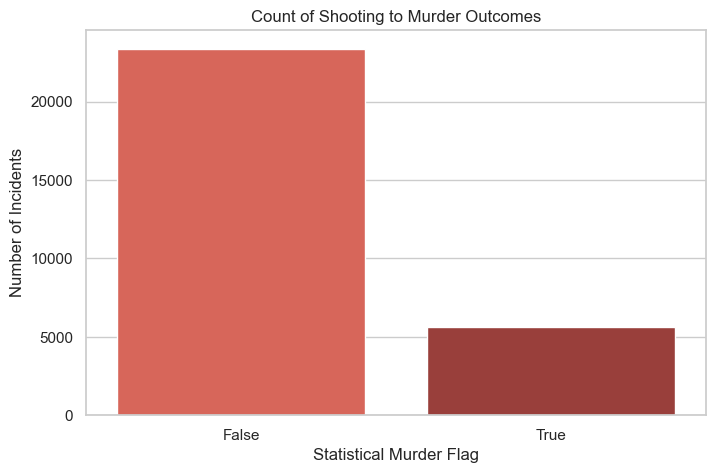

In [85]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart to display the conversion count
sns.barplot(x='statistical_murder_flag', y='Total Incidents', data=conversion_table, palette='Reds_d')


#Formatting Titles/labels
plt.title('Count of Shooting to Murder Outcomes')
plt.xlabel('Statistical Murder Flag')
plt.ylabel('Number of Incidents')
plt.show()

/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_40352/3000921970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='statistical_murder_flag', y='Percentage', data=conversion_table, palette='Reds_d')


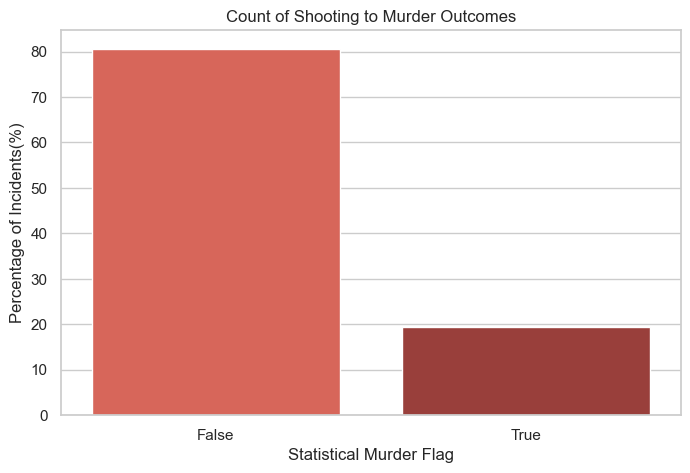

In [ ]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart to display the conversion percentage
sns.barplot(x='statistical_murder_flag', y='Percentage', data=conversion_table, palette='Reds_d')


#Formatting Titles/labels
plt.title('Count of Shooting to Murder Outcomes')
plt.xlabel('Statistical Murder Flag')
plt.ylabel('Percentage of Incidents(%)')
plt.show()

These visualize shows that 

# Shooting-To-Murder Conversion Rate by Age Group

In [ ]:
#Groups by age group [vic_age_group]and murder conversion [statistical_murder_flag]
age_conversion = df.groupby('vic_age_group')['statistical_murder_flag'].mean().reset_index()

age_conversion

,vic_age_group,statistical_murder_flag
0,1022,0.000000
1,18-24,0.165139
2,25-44,0.217820
3,45-64,0.251802
4,65+,0.306034
5,<18,0.131208
6,UNKNOWN,0.220588


In [75]:
# Adds the conversion_rate column multiplying 100 to the statistical_murder_flag column
age_conversion['conversion_rate'] = age_conversion['statistical_murder_flag'] * 100

age_conversion

,vic_age_group,statistical_murder_flag,conversion_rate
0,1022,0.000000,0.000000
1,18-24,0.165139,16.513850
2,25-44,0.217820,21.782029
3,45-64,0.251802,25.180202
4,65+,0.306034,30.603448
5,<18,0.131208,13.120805
6,UNKNOWN,0.220588,22.058824


In [76]:
# Filters out 1022, UNKNOWN from the age group [vic_age_group] column
valid_ages = ['<18', '18-24', '25-44', '45-64', '65+']

age_conversion = age_conversion[age_conversion['vic_age_group'].isin(valid_ages)]

age_conversion

,vic_age_group,statistical_murder_flag,conversion_rate
1,18-24,0.165139,16.513850
2,25-44,0.217820,21.782029
3,45-64,0.251802,25.180202
4,65+,0.306034,30.603448
5,<18,0.131208,13.120805


This dataframe shows that 65+ has the highest shooting-to-murder rate with a conversion rate of 30% 

/var/folders/jk/419dr761613fkh_2fm3hm24w0000gn/T/ipykernel_40352/174063645.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='vic_age_group', y='conversion_rate', data=age_conversion, order=valid_ages, palette='Purples_d')


<Axes: xlabel='vic_age_group', ylabel='conversion_rate'>

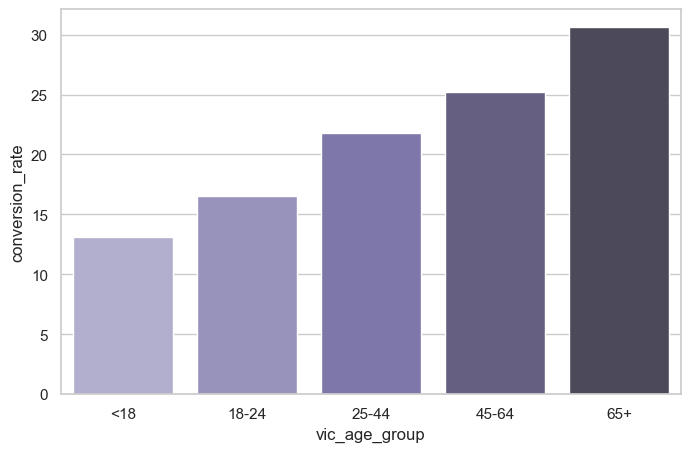

In [78]:
#Sets the chart window to 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

#Using the seaborn library creating a bar chart ordering by youngest to oldest of the conversion rate %
sns.barplot(x='vic_age_group', y='conversion_rate', data=age_conversion, order=valid_ages, palette='Purples_d')